# Yelp Review Polarity: How Preprocessing and Text Representation Affect a Linear Classifier

## Project Overview

This project trains a logistic regression classifier to label Yelp reviews as positive or negative. It then measures how two common pipeline decisions change the result:

- **Preprocessing**: minimal cleaning vs. a full pipeline (stop-word removal and stemming) vs. the same pipeline with negation words kept.
- **Representation**: raw Bag-of-Words counts vs. TF-IDF weights, and unigrams vs. unigrams + bigrams.

All model selection uses a validation set. The test set is used only for the final comparison. A small set of hand-written probe sentences then shows *why* some pipelines fail on negation and contrast ("Not good", "It's not terrible, but...").

**Tools:** Python, Hugging Face `datasets`, scikit-learn, NLTK (Porter stemmer), pandas, matplotlib, seaborn.

## Objective

Build a strong, interpretable sentiment baseline for Yelp reviews, and measure how much each preprocessing and representation choice contributes to accuracy, instead of assuming that more cleaning is always better.

## Dataset

| Property | Value |
|---|---|
| Name | Yelp Review Polarity ([`fancyzhx/yelp_polarity`](https://huggingface.co/datasets/fancyzhx/yelp_polarity) on Hugging Face) |
| Origin | Zhang, Zhao & LeCun (2015), built from the Yelp Dataset Challenge 2015 |
| Size | 560,000 training and 38,000 test reviews, balanced |
| Labels | 0 = negative (1–2 stars), 1 = positive (4–5 stars) |
| Probe sets | `data/case_1_simple.csv` and `data/case_2_contrastive.csv`: 35 short, hand-written movie-review sentences |

The dataset downloads automatically the first time the notebook runs (about 160 MB). Yelp's dataset terms restrict use to non-commercial, academic purposes.

**Sampling.** To keep runtime to a few minutes, the notebook samples:

- 60,000 training reviews and a separate 15,000 validation reviews from the official training split.
- 20,000 test reviews from the official test split.

## Setup and Imports

In [ ]:
import re
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import disable_progress_bars, load_dataset
from huggingface_hub.utils import logging as hf_logging
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score

RANDOM_SEED = 42
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 60_000, 15_000, 20_000
MIN_TOKENS = 5          # training reviews shorter than this after cleaning are dropped
C_GRID = [0.03, 0.1, 0.3, 1, 3, 10, 30]
DATA_DIR = Path("data")
LABEL_NAMES = {0: "negative", 1: "positive"}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
disable_progress_bars()
hf_logging.set_verbosity_error()  # hide Hugging Face download notices

## Data Preparation

In [ ]:
yelp = load_dataset("fancyzhx/yelp_polarity")

train_pool = yelp["train"].shuffle(seed=RANDOM_SEED).select(range(TRAIN_SIZE + VAL_SIZE))
test_sample = yelp["test"].shuffle(seed=RANDOM_SEED).select(range(TEST_SIZE))

splits = {
    "train": train_pool.select(range(TRAIN_SIZE)).to_pandas(),
    "validation": train_pool.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE)).to_pandas(),
    "test": test_sample.to_pandas(),
}
pd.DataFrame({name: {"reviews": len(df), "share_positive": df["label"].mean().round(3)}
              for name, df in splits.items()}).T

,reviews,share_positive
train,60000.0,0.497
validation,15000.0,0.503
test,20000.0,0.499


### Three preprocessing pipelines

All three pipelines start the same way:

1. Lowercase the text.
2. Replace the literal `\n` sequences that this dataset uses for line breaks.
3. Expand common contractions (`didn't` → `did not`).
4. Keep only letters.

They then differ as follows:

| Pipeline | Stop words removed | Stemming |
|---|---|---|
| `minimal` | No | No |
| `full` | scikit-learn's English list (318 words) | Porter |
| `negation_aware` | Same list, but 20 negation and contrast words are kept | Porter |

The scikit-learn stop list includes *not*, *no*, *never*, *nothing*, and *but*. The `full` pipeline therefore turns "not good" into "good", a problem the probe sentences later make visible.

In [ ]:
NEGATION_AND_CONTRAST = {
    "not", "no", "nor", "never", "cannot", "none", "nothing", "nobody", "neither", "without",
    "against", "but", "however", "although", "very", "too", "few", "less", "more", "most",
}
STOP_WORDS = {
    "full": set(ENGLISH_STOP_WORDS),
    "negation_aware": set(ENGLISH_STOP_WORDS) - NEGATION_AND_CONTRAST,
}
CONTRACTIONS = [
    (r"won't", "will not"), (r"can't", "can not"), (r"n't\b", " not"), (r"'re\b", " are"),
    (r"'m\b", " am"), (r"'ll\b", " will"), (r"'ve\b", " have"), (r"'d\b", " would"),
]
stemmer = PorterStemmer()
cached_stem = lru_cache(maxsize=None)(stemmer.stem)


def clean_review(text, pipeline):
    text = text.lower().replace("\\n", " ").replace("’", "'")
    for pattern, replacement in CONTRACTIONS:
        text = re.sub(pattern, replacement, text)
    tokens = re.sub(r"[^a-z]+", " ", text).split()
    if pipeline == "minimal":
        return " ".join(tokens)
    stop_words = STOP_WORDS[pipeline]
    return " ".join(cached_stem(t) for t in tokens if t not in stop_words and len(t) > 1)


PIPELINES = ["minimal", "full", "negation_aware"]
for df in splits.values():
    for pipeline in PIPELINES:
        df[pipeline] = df["text"].map(lambda text: clean_review(text, pipeline))

In [ ]:
# A short review with a contraction shows the differences clearly
train_text = splits["train"]["text"]
example = splits["train"][train_text.str.contains("n't") & train_text.str.len().between(150, 350)].iloc[0]
print("RAW:           ", example["text"][:300])
for pipeline in PIPELINES:
    print(f"{pipeline + ':':<16}", example[pipeline][:300])

RAW:            This spot just doesn't do it for me.  Flavors fall short.  Vegetables are over cooked and soggy.  \n\nThe service is fine. The location is nice. Overall the food was mediocre.
minimal:         this spot just does not do it for me flavors fall short vegetables are over cooked and soggy the service is fine the location is nice overall the food was mediocre
full:            spot just doe flavor fall short veget cook soggi servic fine locat nice overal food mediocr
negation_aware:  spot just doe not flavor fall short veget cook soggi servic fine locat nice overal food mediocr


Very short training reviews are dropped after cleaning, because a few remaining tokens carry little signal. This filter applies **only to training data**. Validation and test reviews are never removed, so the reported scores cover every review.

In [ ]:
cleaning_stats = []
for pipeline in PIPELINES:
    lengths = splits["train"][pipeline].str.split().str.len()
    cleaning_stats.append({
        "Pipeline": pipeline,
        "Avg tokens before": splits["train"]["text"].str.split().str.len().mean(),
        "Avg tokens after": lengths.mean(),
        f"Train reviews with < {MIN_TOKENS} tokens": int((lengths < MIN_TOKENS).sum()),
    })
pd.DataFrame(cleaning_stats).set_index("Pipeline").round(1)

,Avg tokens before,Avg tokens after,Train reviews with < 5 tokens
Pipeline,,,
minimal,132.8,135.7,277
full,132.8,57.8,784
negation_aware,132.8,62.7,669


## Exploratory Analysis

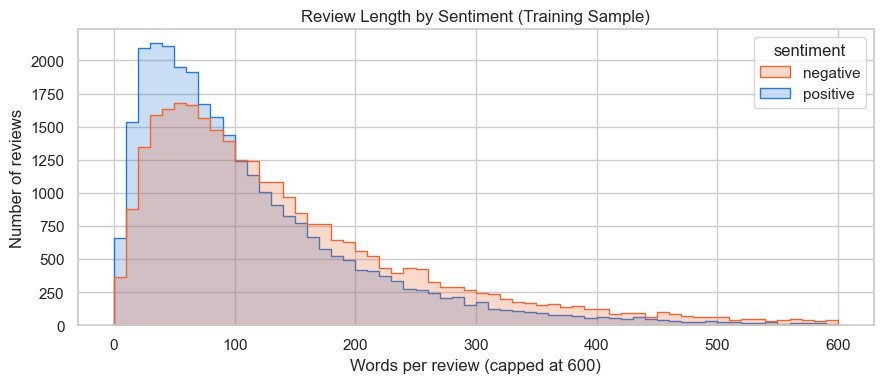

sentiment
negative    112.0
positive     84.0
Name: median words, dtype: float64

In [ ]:
review_lengths = splits["train"].assign(
    words=splits["train"]["text"].str.split().str.len(),
    sentiment=splits["train"]["label"].map(LABEL_NAMES),
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=review_lengths, x="words", hue="sentiment", hue_order=["negative", "positive"],
             palette={"negative": "#eb6834", "positive": "#2a78d6"},
             bins=60, binrange=(0, 600), element="step", ax=ax)
ax.set_title("Review Length by Sentiment (Training Sample)")
ax.set_xlabel("Words per review (capped at 600)")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

review_lengths.groupby("sentiment")["words"].median().rename("median words")

### Document-term matrix

A unigram Bag-of-Words matrix fitted on the `full` pipeline shows how sparse these representations are.

In [ ]:
full_train = splits["train"][splits["train"]["full"].str.split().str.len() >= MIN_TOKENS]
bow_full = CountVectorizer(min_df=2)
X_bow_full = bow_full.fit_transform(full_train["full"])

density = X_bow_full.nnz / np.prod(X_bow_full.shape)
print(f"Matrix shape: {X_bow_full.shape[0]:,} reviews x {X_bow_full.shape[1]:,} terms")
print(f"Non-zero entries: {density:.3%}  (sparsity {1 - density:.3%})")

term_totals = pd.Series(np.asarray(X_bow_full.sum(axis=0)).ravel(), index=bow_full.get_feature_names_out())
term_totals.nlargest(15).rename("count").to_frame().T

Matrix shape: 59,216 reviews x 24,620 terms
Non-zero entries: 0.189%  (sparsity 99.811%)


,place,food,good,like,time,just,order,did,servic,great,realli,tri,look,want,got
count,39065,36660,32832,30975,29763,28164,26166,23962,23933,22686,18034,17450,14727,14670,14520


## Model Development

### Experiment grid

Each combination of pipeline and representation is paired with logistic regression. The regularization strength `C` is chosen on the validation set. Vectorizers are always fitted on training data only. Terms that appear in fewer than two training reviews are ignored (`min_df=2`).

In [ ]:
def make_vectorizer(representation, ngram_range):
    vectorizer_class = TfidfVectorizer if representation == "TF-IDF" else CountVectorizer
    extra = {"sublinear_tf": True} if representation == "TF-IDF" else {}
    return vectorizer_class(ngram_range=ngram_range, min_df=2, **extra)


def run_experiment(pipeline, representation, ngram_range=(1, 1)):
    """Fit the vectorizer on training data, tune C on validation, and return the best model."""
    train = splits["train"][splits["train"][pipeline].str.split().str.len() >= MIN_TOKENS]
    vectorizer = make_vectorizer(representation, ngram_range)
    X_train = vectorizer.fit_transform(train[pipeline])
    X_val = vectorizer.transform(splits["validation"][pipeline])

    best = None
    for C in C_GRID:
        model = LogisticRegression(C=C, max_iter=3000, random_state=RANDOM_SEED).fit(X_train, train["label"])
        val_f1 = f1_score(splits["validation"]["label"], model.predict(X_val))
        if best is None or val_f1 > best["val_f1"]:
            best = {"C": C, "val_f1": val_f1, "model": model}
    return {"pipeline": pipeline, "representation": representation, "ngrams": ngram_range,
            "vocabulary": len(vectorizer.vocabulary_), "vectorizer": vectorizer, **best}


experiments = [
    run_experiment(pipeline, representation)
    for pipeline in PIPELINES
    for representation in ["BoW", "TF-IDF"]
]

### Adding bigrams

Bigrams let a linear model learn phrases such as *not good* or *never again* as single features. Bigrams are added to the best unigram configuration found on the validation set.

In [ ]:
best_unigram = max(experiments, key=lambda e: e["val_f1"])
experiments.append(run_experiment(best_unigram["pipeline"], best_unigram["representation"], ngram_range=(1, 2)))


def describe(experiment):
    ngram_label = "1-2" if experiment["ngrams"] == (1, 2) else "1"
    return f"{experiment['pipeline']} | {experiment['representation']} | n-grams {ngram_label}"


pd.DataFrame([
    {"Configuration": describe(e), "Vocabulary": e["vocabulary"], "Best C": e["C"], "Validation F1": e["val_f1"]}
    for e in experiments
]).set_index("Configuration").round(4)

,Vocabulary,Best C,Validation F1
Configuration,,,
minimal | BoW | n-grams 1,36360,0.1,0.9232
minimal | TF-IDF | n-grams 1,36360,3.0,0.9267
full | BoW | n-grams 1,24620,0.1,0.9096
full | TF-IDF | n-grams 1,24620,3.0,0.9128
negation_aware | BoW | n-grams 1,24636,0.1,0.9154
negation_aware | TF-IDF | n-grams 1,24636,3.0,0.9185
minimal | TF-IDF | n-grams 1-2,460702,30.0,0.9417


## Model Evaluation

Every configuration is scored once on the 20,000 held-out test reviews, which none of the tuning steps used.

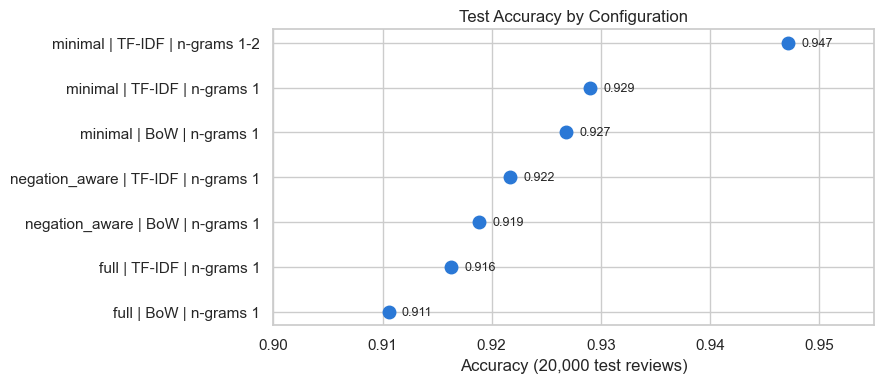

,Accuracy,F1
Configuration,,
minimal | BoW | n-grams 1,0.9268,0.9270
minimal | TF-IDF | n-grams 1,0.9290,0.9288
full | BoW | n-grams 1,0.9106,0.9109
full | TF-IDF | n-grams 1,0.9163,0.9164
negation_aware | BoW | n-grams 1,0.9188,0.9191
negation_aware | TF-IDF | n-grams 1,0.9217,0.9217
minimal | TF-IDF | n-grams 1-2,0.9472,0.9470


In [ ]:
y_test = splits["test"]["label"]
test_rows = []
for e in experiments:
    X_test = e["vectorizer"].transform(splits["test"][e["pipeline"]])
    e["test_pred"] = e["model"].predict(X_test)
    test_rows.append({
        "Configuration": describe(e),
        "Accuracy": accuracy_score(y_test, e["test_pred"]),
        "F1": f1_score(y_test, e["test_pred"]),
    })

test_results = pd.DataFrame(test_rows).set_index("Configuration")

# Dot plot: differences are small, so a zoomed axis is clearer than bars
fig, ax = plt.subplots(figsize=(9, 4))
plot_data = test_results["Accuracy"].sort_values()
ax.plot(plot_data.values, plot_data.index, "o", color="#2a78d6", markersize=9)
ax.set_xlim(0.90, 0.955)
ax.set_title("Test Accuracy by Configuration")
ax.set_xlabel("Accuracy (20,000 test reviews)")
for y, value in enumerate(plot_data.values):
    ax.text(value + 0.0012, y, f"{value:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

test_results.round(4)

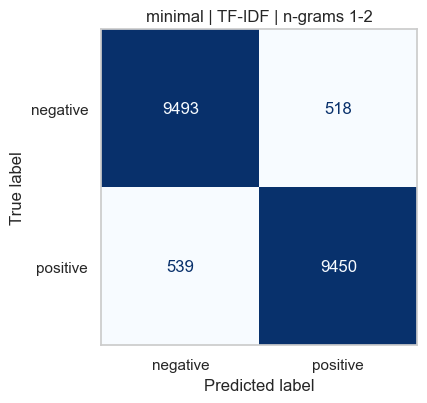

In [ ]:
final_model = experiments[-1]
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test.map(LABEL_NAMES), pd.Series(final_model["test_pred"]).map(LABEL_NAMES),
    cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title(describe(final_model))
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.grid(False)
plt.tight_layout()
plt.show()

## Error Analysis

### 1. Probe sentences: simple vs. contrastive language

The two probe sets contain short movie-review sentences. Note that the domain differs from Yelp's restaurant and business reviews.

- **Case 1** uses explicit sentiment words ("an excellent and amazing film").
- **Case 2** relies on negation and contrast ("It's not terrible, but I wouldn't recommend it").

Bag-of-Words assumes word order does not matter and that each word contributes independently to the label. Case 2 is designed to break that assumption.

In [ ]:
probe_sets = {
    "Case 1 (simple)": pd.read_csv(DATA_DIR / "case_1_simple.csv"),
    "Case 2 (contrastive)": pd.read_csv(DATA_DIR / "case_2_contrastive.csv"),
}

selected = {describe(e): e for e in experiments if e["representation"] == "TF-IDF"}
probe_rows = []
for config_name, e in selected.items():
    row = {"Configuration": config_name}
    for set_name, probe in probe_sets.items():
        cleaned = probe["text"].map(lambda text: clean_review(text, e["pipeline"]))
        row[set_name] = accuracy_score(probe["label"], e["model"].predict(e["vectorizer"].transform(cleaned)))
    probe_rows.append(row)

pd.DataFrame(probe_rows).set_index("Configuration").round(3)

,Case 1 (simple),Case 2 (contrastive)
Configuration,,
minimal | TF-IDF | n-grams 1,1.000,0.40
full | TF-IDF | n-grams 1,0.933,0.65
negation_aware | TF-IDF | n-grams 1,1.000,0.55
minimal | TF-IDF | n-grams 1-2,1.000,0.60


The cleaned versions of a few Case 2 sentences show what each model actually sees:

In [ ]:
contrastive = probe_sets["Case 2 (contrastive)"]
examples = contrastive.iloc[[0, 5, 11, 12, 16]].copy()
for pipeline in PIPELINES:
    examples[pipeline] = examples["text"].map(lambda text: clean_review(text, pipeline))
examples["label"] = examples["label"].map(LABEL_NAMES)
examples

,text,label,minimal,full,negation_aware
0,"Not perfect, but I enjoyed it a lot.",positive,not perfect but i enjoyed it a lot,perfect enjoy lot,not perfect but enjoy lot
5,Not bad at all -- actually pretty solid.,positive,not bad at all actually pretty solid,bad actual pretti solid,not bad actual pretti solid
11,Not good -- just noisy and dull.,negative,not good just noisy and dull,good just noisi dull,not good just noisi dull
12,"It's not terrible, but I wouldn't recommend it.",negative,it s not terrible but i would not recommend it,terribl recommend,not terribl but not recommend
16,"Good cast, bad movie.",negative,good cast bad movie,good cast bad movi,good cast bad movi


### 2. What the final model learned

The largest positive and negative coefficients show which features drive predictions. Bigrams that contain negations appear among the strongest features.

In [ ]:
coefficients = pd.Series(final_model["model"].coef_[0], index=final_model["vectorizer"].get_feature_names_out())
pd.DataFrame({
    "Strongest negative features": coefficients.nsmallest(15).index,
    "Strongest positive features": coefficients.nlargest(15).index,
})

,Strongest negative features,Strongest positive features
0,bland,great
1,not,delicious
2,mediocre,awesome
3,worst,amazing
4,not worth,excellent
5,horrible,fantastic
6,terrible,love
7,overpriced,definitely
8,rude,perfect
9,awful,good


In [ ]:
negation_bigrams = coefficients[coefficients.index.str.match(r"^(not|no|never) ")]
pd.concat([negation_bigrams.nsmallest(8), negation_bigrams.nlargest(8)]).rename("coefficient").round(2).to_frame().T

,not worth,not good,not impressed,not very,not even,not recommend,not so,not great,not too,not bad,not disappointed,not wait,never had,not miss,no complaints,not disappoint
coefficient,-20.79,-15.26,-12.62,-12.29,-11.43,-11.36,-10.61,-10.05,12.3,9.33,6.78,6.36,6.24,5.95,5.48,4.87


### 3. Error rate by review length and confident mistakes

In [ ]:
test_analysis = splits["test"].assign(
    words=splits["test"]["text"].str.split().str.len(),
    correct=final_model["test_pred"] == y_test,
    positive_probability=final_model["model"].predict_proba(
        final_model["vectorizer"].transform(splits["test"][final_model["pipeline"]]))[:, 1],
)
test_analysis["length_bucket"] = pd.qcut(test_analysis["words"], q=5)
(1 - test_analysis.groupby("length_bucket", observed=True)["correct"].mean()).rename("error rate").round(3).to_frame().T

length_bucket,"(0.999, 43.0]","(43.0, 77.0]","(77.0, 121.0]","(121.0, 198.0]","(198.0, 988.0]"
error rate,0.058,0.05,0.057,0.048,0.051


In [ ]:
test_analysis["confidence_in_wrong_label"] = np.where(
    test_analysis["label"] == 1, 1 - test_analysis["positive_probability"], test_analysis["positive_probability"]
)
confident_errors = test_analysis[~test_analysis["correct"]].nlargest(6, "confidence_in_wrong_label")
with pd.option_context("display.max_colwidth", 300):
    display(confident_errors.assign(true_label=confident_errors["label"].map(LABEL_NAMES))[
        ["true_label", "confidence_in_wrong_label", "text"]].round(3))

,true_label,confidence_in_wrong_label,text
512,negative,1.000,"Wow love the place and everything is very clean and new!\n\nGreat place to come and relax worth a try!\n\nCheers,\n\nEric Van Nguyen\nVisited April 2012"
6543,positive,0.999,"The food is crap. I'm not trying to be mean, but it really is horrible. I'd rather eat one of those Tornado things from Circle K for dinner. Also, I don't appreciate the waitress telling me everything is great when everything is absolutely not great. What kind of disgusting excuse for food m..."
1376,positive,0.999,"Everything is great about this place, with the exception of the food, which was okay. The layout, and design of the location is great, and the staff is extremely friendly. However I wasn't crazy over the food, there just wasn't enough flavor. I ordered the Asparagus Fusilli which I found to b..."
19512,positive,0.999,"EDIT: They really did change the service up since I last posted this.\n\nHorrible service.\n\nUsed to be my favorite pizza in the city (at a reasonable price), but I'm rethinking that. We just had an altercation with a server who refused to split a check when we were paying with cash. He then pr..."
16267,positive,0.998,Last night several parents came in with over 15 children to celebrate their 9 year olds 4th grade graduation at 9:15 pm. The bartender expressed that it was not a place to have children running around as it is against the law and a liability issue if anything were to happen to them on their prem...
852,negative,0.998,What I love about Rubios' is that they always have beer. Always.\n\nThat is all I love though...


## Key Findings

| Configuration (pipeline, representation, n-grams) | Test accuracy | Test F1 |
|---|---|---|
| full (stop words + stemming), BoW, unigrams | 0.911 | 0.911 |
| full, TF-IDF, unigrams | 0.916 | 0.916 |
| negation-aware, TF-IDF, unigrams | 0.922 | 0.922 |
| minimal, TF-IDF, unigrams | 0.929 | 0.929 |
| **minimal, TF-IDF, unigrams + bigrams** | **0.947** | **0.947** |

- **Aggressive cleaning hurts sentiment classification.** Removing stop words and stemming cut the average review from about 133 to 58 tokens, and it also reduced accuracy by 1.3 points compared to minimal cleaning. The standard stop list removes words that carry sentiment. One example: *doesn't* becomes *does not*, *not* is removed as a stop word, and *does* is stemmed to *doe*.
- **Keeping negation words recovers about half of that loss** (0.916 → 0.922). The remaining gap comes from other removed words and from stemming.
- **TF-IDF beats raw counts by a small, consistent margin** in every pipeline (+0.2 to +0.6 points).
- **Bigrams give the largest single gain** (+1.8 points over the best unigram model). The strongest negation bigrams show why. *not worth*, *not good*, and *not impressed* are strongly negative, while *not bad*, *not disappointed*, and *not wait* (from "can't wait") are strongly positive, which a unigram model cannot express.
- **Contrastive sentences remain hard for every model.** All models classify the simple probe sentences almost perfectly but get only 40–65% of the 20 contrastive sentences right. With so few examples, the differences between models on Case 2 are not reliable. For instance, the `full` pipeline scores highest, partly because removing *not* happens to help on several "not bad"-style sentences.
- **Error rates barely depend on review length** (4.8–5.8% across length quintiles). Several of the most confident "errors" look like label noise, such as an enthusiastic review labeled negative and a review calling the food "crap" labeled positive. This suggests the model is close to the ceiling the labels allow for this approach.

## Limitations

- The models are trained on a 60,000-review sample. Training on the full 560,000 reviews would likely add a small amount of accuracy.
- The probe sets are tiny (15 and 20 sentences) and come from a different domain (movies). They illustrate failure modes but are not a reliable accuracy estimate.
- Bigrams capture only short-range negation. Longer constructions ("I expected to hate it, but it won me over") still require models that represent word order and context.

## Next Steps

- Fine-tune a pretrained transformer (for example, DistilBERT) and compare it on the same test sample and probe sets.
- Add explicit negation scope marking (for example, appending `_NEG` to tokens after *not* until the next punctuation mark) as a lightweight alternative to bigrams.
- Train on the full training split with a hashing vectorizer to keep memory usage manageable.

## Attribution

- Dataset: Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level Convolutional Networks for Text Classification.* NeurIPS. Derived from the Yelp Dataset Challenge 2015 and distributed via Hugging Face